In [1]:
from __future__ import print_function, division
from arch_config import *
import torch
import torch.nn as nn
from torch.optim import lr_scheduler
import torchvision
from torchvision import models
import matplotlib.pyplot as plt
import numpy as np
import time
import os
import copy
import kagglehub
import shutil

In [2]:
def create_model_parameters():

  res_mod_silu = models.resnet50(weights='IMAGENET1K_V2')

  for param in res_mod_silu.parameters():
        param.requires_grad = False

  res_mod_silu.fc = nn.Sequential(
    nn.Linear(2048, 1024),
    nn.SiLU(),
    nn.Dropout(p=0.4),
    nn.Linear(1024, 512),
    nn.SiLU(),
    nn.Linear(512, 9),
  )

  res_mod_silu = res_mod_silu.to(device)

  criterion = nn.CrossEntropyLoss()
  optimizer_silu = torch.optim.AdamW(filter(lambda x: x.requires_grad, res_mod_silu.parameters()), lr=0.0001, weight_decay=0.0001)
  exp_lr_scheduler = lr_scheduler.CosineAnnealingLR(optimizer_silu, T_max=30, eta_min=1e-6)

  return res_mod_silu, criterion, optimizer_silu, exp_lr_scheduler

In [3]:
# data
dataloaders, class_names, dataset_sizes, vis_loader = get_dataloaders50()
train_set, val_set, test_set = dataloaders['train'], dataloaders['val'], dataloaders['test']

In [4]:
model_2048, criterion, optimizer, scheduler = create_model_parameters()

In [5]:
final_model, metrics = train_model(model_2048, criterion, optimizer, scheduler, dataloaders, dataset_sizes, 25)

val Loss: 0.7434 | Acc: 0.7484 | Weighted Acc: 0.7194 | F1-macro: 0.7531 | Top-1 Acc: 0.7484 | Top-3 Acc: 0.9438
Epoch Time: 32.1315s

Training complete in 13m 16s
Best val Weighted Acc: 0.734238 | Best F1-score: 0.7652 | Best Top-1 Acc: 0.7598 | Best Top-3 Acc: 0.9479


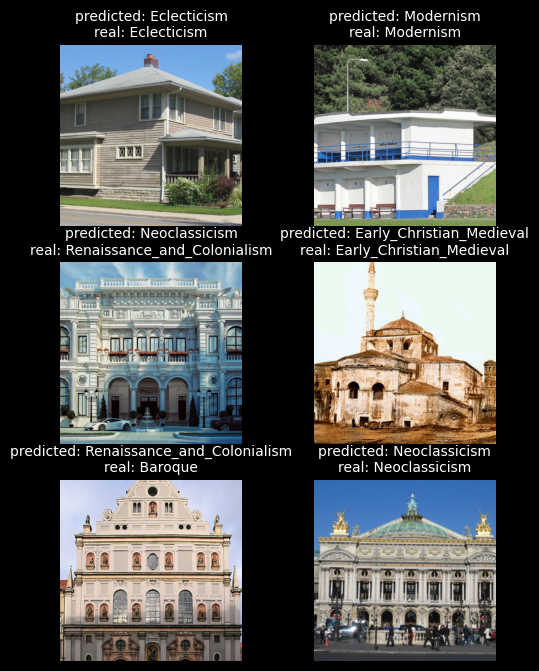

In [6]:
visualize_model(final_model, num_images=6, class_names=class_names, vis_loader=vis_loader)

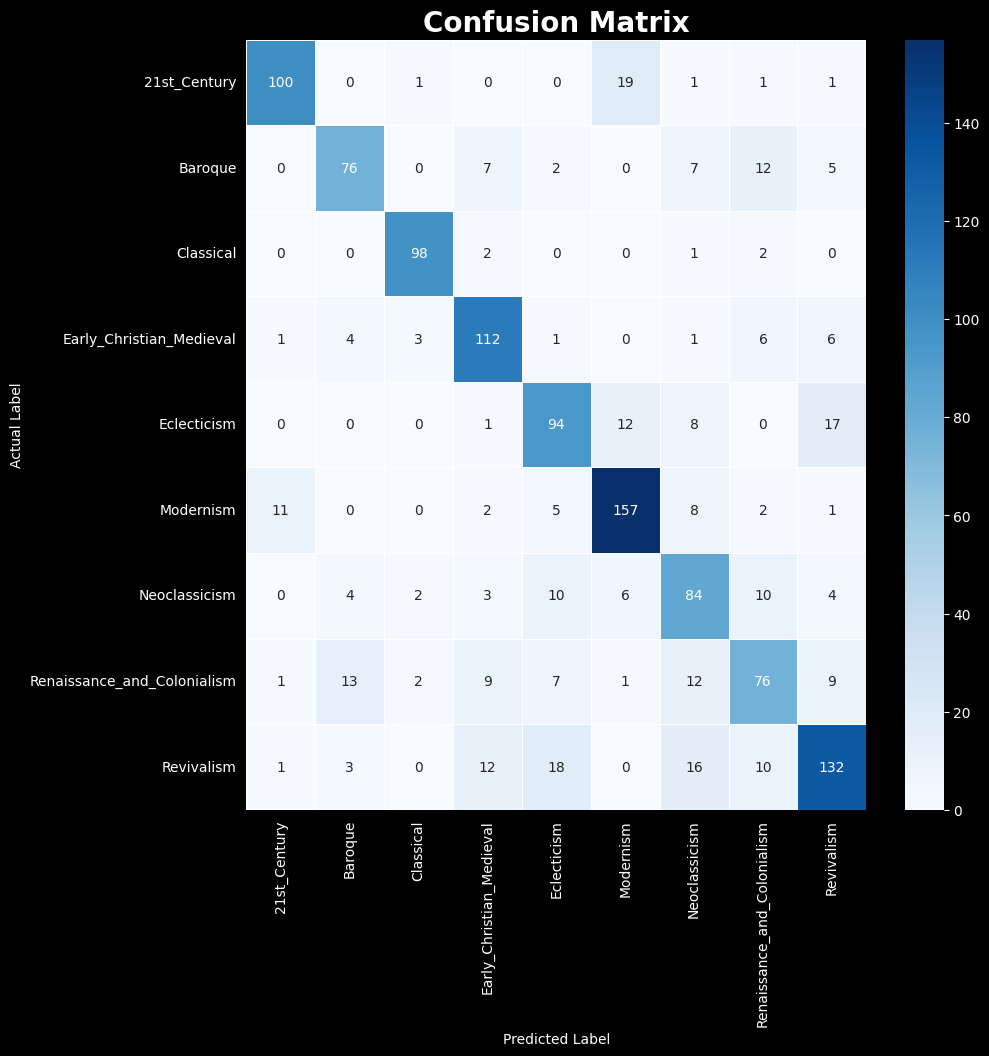

In [7]:
visualize_cm(final_model, class_names, test_set)

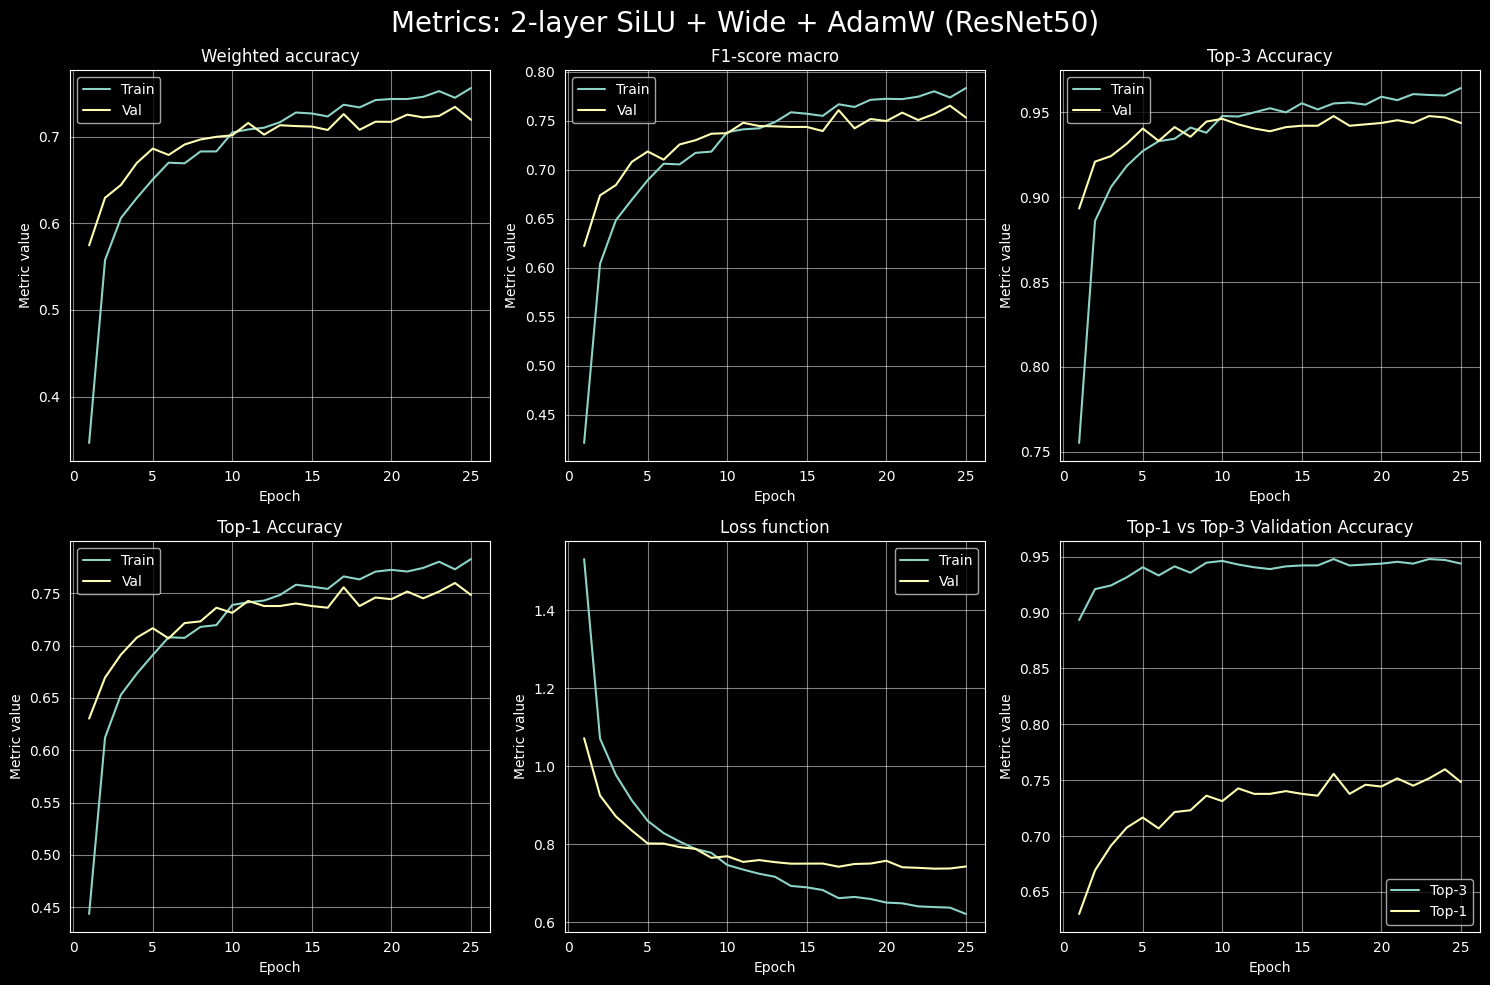

In [8]:
visualize_metrics(metrics, "Metrics: 2-layer SiLU + Wide + AdamW (ResNet50)", 25)

In [9]:
torch.save(final_model, 'wide&deep_50.pt')